In [1]:
# ============================================
# CUSTOMER SEGMENTATION & PREDICTION
# Week 11 - Advanced Machine Learning Models
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("customer_segmentation.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (500, 9)


In [3]:
# Display the first 5 rows
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB


In [5]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']

Categorical columns:
['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling']


In [8]:
# Create dataset for customer segmentation

clustering_df = df.drop(columns=["CustomerID", "Churn"]).copy()

print("Clustering dataset shape:", clustering_df.shape)
print("\nColumns used for clustering:")
print(list(clustering_df.columns))

Clustering dataset shape: (500, 7)

Columns used for clustering:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']


In [9]:
# Convert categorical variables into numerical format

clustering_encoded = pd.get_dummies(
    clustering_df,
    columns=categorical_columns.drop("CustomerID", errors="ignore"),
    drop_first=True,
    dtype=int
)

print("Encoded dataset shape:", clustering_encoded.shape)
print("\nEncoded columns:")
print(list(clustering_encoded.columns))

Encoded dataset shape: (500, 9)

Encoded columns:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check', 'PaperlessBilling_Yes']


In [10]:
# Standardize features for clustering

scaler = StandardScaler()

clustering_scaled = scaler.fit_transform(clustering_encoded)

print("Scaled dataset shape:", clustering_scaled.shape)
print("Scaling completed successfully!")

Scaled dataset shape: (500, 9)
Scaling completed successfully!


In [11]:
# Elbow Method for determining the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(clustering_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: {value:.2f}")

Inertia values:
K = 2: 3863.21
K = 3: 3422.64
K = 4: 3157.63
K = 5: 2966.18
K = 6: 2867.47
K = 7: 2730.69
K = 8: 2614.94
K = 9: 2545.78
K = 10: 2489.74


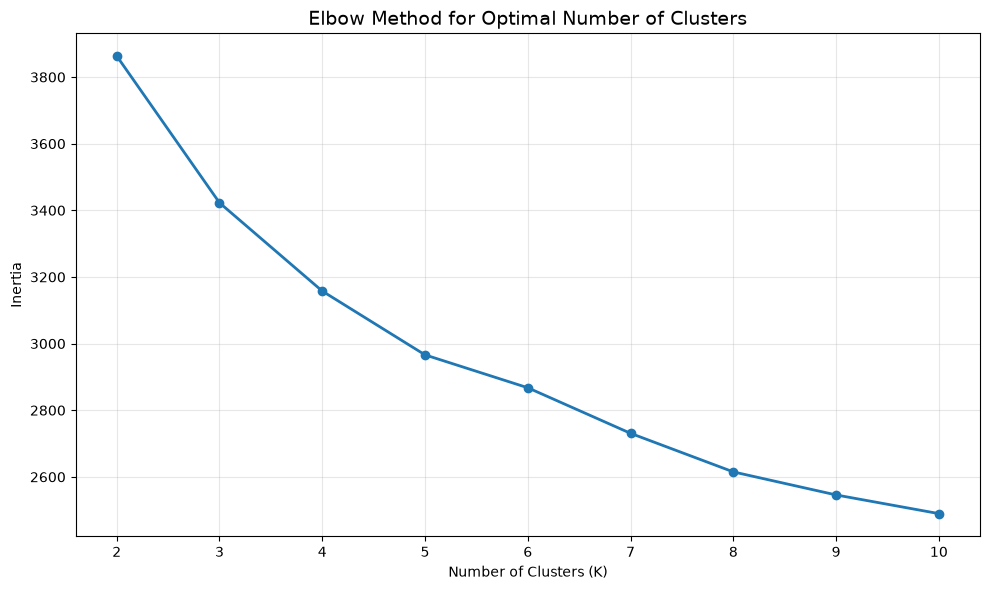

In [12]:
# Plot the Elbow Method

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("visualizations/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Apply K-Means clustering with 5 clusters

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(clustering_scaled)

# Add cluster labels to the original dataset
df["Cluster"] = cluster_labels

print("K-Means clustering completed successfully!")
print("\nCluster distribution:")
print(df["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Cluster distribution:
Cluster
0     97
1    101
2    116
3     62
4    124
Name: count, dtype: int64


In [14]:
# Analyze the characteristics of each cluster

cluster_profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Tenure=("Tenure", "mean"),
    Avg_MonthlyCharges=("MonthlyCharges", "mean"),
    Avg_TotalCharges=("TotalCharges", "mean"),
    Avg_SeniorCitizen=("SeniorCitizen", "mean"),
    Churn_Rate=("Churn", "mean")
).round(2)

print("Customer Segment Profiles:")
display(cluster_profile)

Customer Segment Profiles:


,Customers,Avg_Tenure,Avg_MonthlyCharges,Avg_TotalCharges,Avg_SeniorCitizen,Churn_Rate
Cluster,,,,,,
0,97,34.88,110.90,4597.04,0.55,0.07
1,101,36.28,121.08,4165.61,0.46,0.14
2,116,36.35,108.85,4260.77,0.55,0.21
3,62,36.16,111.52,4273.73,0.48,0.06
4,124,38.39,115.25,3976.46,0.45,0.03


In [15]:
# Analyze categorical characteristics of each cluster

categorical_profile = {}

for column in ["Contract", "PaymentMethod", "PaperlessBilling"]:
    categorical_profile[column] = pd.crosstab(
        df["Cluster"],
        df[column],
        normalize="index"
    ).round(2)

for column, profile in categorical_profile.items():
    print(f"\n{column} distribution by cluster:")
    display(profile)


Contract distribution by cluster:


Contract,Month-to-month,One year,Two year
Cluster,,,
0,0.00,0.0,1.00
1,0.53,0.0,0.47
2,1.00,0.0,0.00
3,0.00,1.0,0.00
4,0.00,1.0,0.00



PaymentMethod distribution by cluster:


PaymentMethod,Bank Transfer,Credit Card,Electronic Check
Cluster,,,
0,0.44,0.56,0.0
1,0.00,0.00,1.0
2,0.44,0.56,0.0
3,0.00,0.00,1.0
4,0.52,0.48,0.0



PaperlessBilling distribution by cluster:


PaperlessBilling,No,Yes
Cluster,,
0,0.44,0.56
1,0.59,0.41
2,0.56,0.44
3,0.45,0.55
4,0.49,0.51


In [16]:
# Contract distribution by cluster

contract_profile = pd.crosstab(
    df["Cluster"],
    df["Contract"],
    normalize="index"
).round(2)

display(contract_profile)

Contract,Month-to-month,One year,Two year
Cluster,,,
0,0.00,0.0,1.00
1,0.53,0.0,0.47
2,1.00,0.0,0.00
3,0.00,1.0,0.00
4,0.00,1.0,0.00


In [17]:
# Payment method distribution by cluster

payment_profile = pd.crosstab(
    df["Cluster"],
    df["PaymentMethod"],
    normalize="index"
).round(2)

display(payment_profile)

PaymentMethod,Bank Transfer,Credit Card,Electronic Check
Cluster,,,
0,0.44,0.56,0.0
1,0.00,0.00,1.0
2,0.44,0.56,0.0
3,0.00,0.00,1.0
4,0.52,0.48,0.0


In [18]:
# Assign meaningful business-oriented names to the clusters

segment_names = {
    0: "Long-Term Customers",
    1: "High-Charge Electronic Check Customers",
    2: "Month-to-Month At-Risk Customers",
    3: "One-Year Electronic Check Customers",
    4: "Low-Churn One-Year Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

# Display segment distribution
segment_distribution = (
    df["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_distribution["Percentage"] = (
    segment_distribution["Customers"] / len(df) * 100
).round(2)

display(segment_distribution)

,Segment,Customers,Percentage
0,Low-Churn One-Year Customers,124,24.8
1,Month-to-Month At-Risk Customers,116,23.2
2,High-Charge Electronic Check Customers,101,20.2
3,Long-Term Customers,97,19.4
4,One-Year Electronic Check Customers,62,12.4


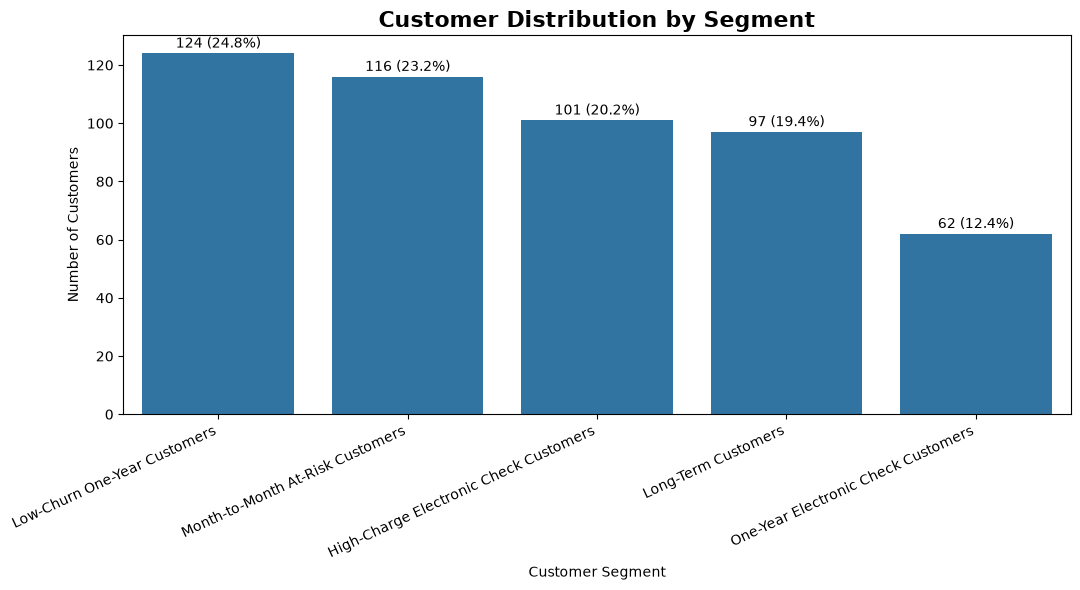

In [19]:
# Visualize customer distribution across segments

plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_distribution,
    x="Segment",
    y="Customers"
)

plt.title("Customer Distribution by Segment", fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")

# Add value labels
for i, row in segment_distribution.iterrows():
    plt.text(
        i,
        row["Customers"] + 2,
        f'{row["Customers"]} ({row["Percentage"]:.1f}%)',
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "visualizations/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Reduce clustering features to 2 dimensions using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(clustering_scaled)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = df["Cluster"]

print("PCA visualization data created successfully!")
print("Explained variance:")
print(f"PCA1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PCA2: {pca.explained_variance_ratio_[1]:.2%}")
print(
    f"Total explained variance: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

PCA visualization data created successfully!
Explained variance:
PCA1: 17.73%
PCA2: 16.37%
Total explained variance: 34.10%


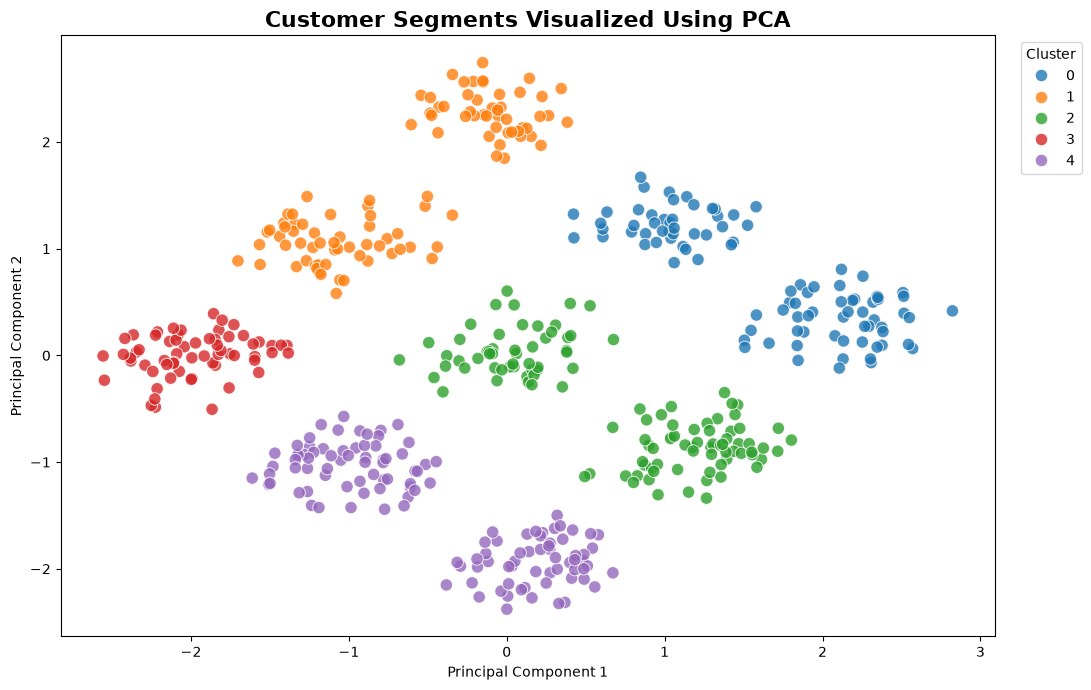

In [21]:
# Visualize K-Means clusters using PCA

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    s=80,
    alpha=0.8
)

plt.title("Customer Segments Visualized Using PCA", fontsize=16, fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.savefig(
    "visualizations/kmeans_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Import libraries for Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [23]:
# Apply Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(clustering_scaled)

# Calculate silhouette score
hierarchical_silhouette = silhouette_score(
    clustering_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering completed successfully!")
print("\nCluster distribution:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

print(f"\nSilhouette Score: {hierarchical_silhouette:.4f}")

Hierarchical Clustering completed successfully!

Cluster distribution:
0    145
1     98
2    119
3     91
4     47
Name: count, dtype: int64

Silhouette Score: 0.1309


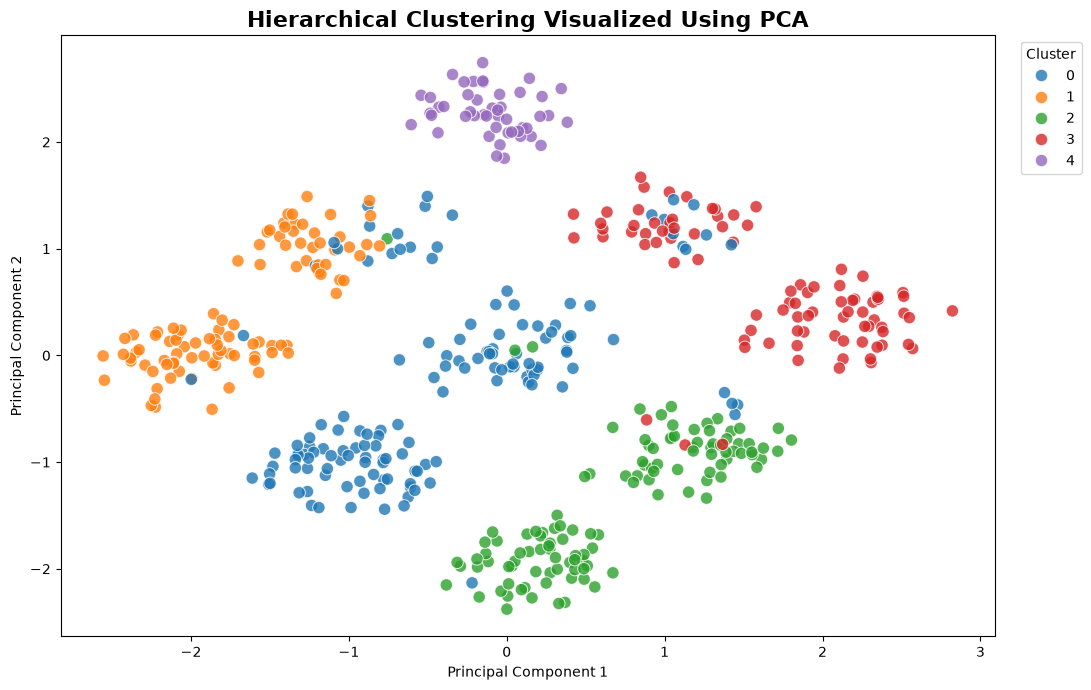

In [24]:
# Visualize Hierarchical Clusters using PCA

hierarchical_pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

hierarchical_pca_df["Cluster"] = hierarchical_labels

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=hierarchical_pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    s=80,
    alpha=0.8
)

plt.title(
    "Hierarchical Clustering Visualized Using PCA",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "visualizations/hierarchical_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [25]:
# Import DBSCAN

from sklearn.cluster import DBSCAN

In [26]:
# Apply DBSCAN clustering

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(clustering_scaled)

# Count clusters and noise points
unique_labels = set(dbscan_labels)

n_clusters = len(unique_labels - {-1})
n_noise = list(dbscan_labels).count(-1)

print("DBSCAN completed successfully!")
print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

print("\nCluster distribution:")
print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

DBSCAN completed successfully!

Number of clusters: 2
Number of noise points: 490

Cluster distribution:
-1    490
 0      5
 1      5
Name: count, dtype: int64


In [27]:
# Test different DBSCAN eps values

eps_values = [0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

dbscan_results = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(clustering_scaled)

    n_clusters = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": round((n_noise / len(labels)) * 100, 2)
    })

dbscan_comparison = pd.DataFrame(dbscan_results)

display(dbscan_comparison)

,eps,clusters,noise_points,noise_percentage
0,0.8,2,490,98.0
1,1.0,6,469,93.8
2,1.2,16,396,79.2
3,1.4,30,277,55.4
4,1.6,34,152,30.4
5,1.8,36,69,13.8
6,2.0,35,32,6.4


In [28]:
# Final DBSCAN model

dbscan_final = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels_final = dbscan_final.fit_predict(clustering_scaled)

# Count clusters and noise
dbscan_cluster_count = len(set(dbscan_labels_final) - {-1})
dbscan_noise_count = list(dbscan_labels_final).count(-1)

print("Final DBSCAN Results")
print("--------------------")
print(f"Number of clusters: {dbscan_cluster_count}")
print(f"Noise points: {dbscan_noise_count}")
print(
    f"Noise percentage: "
    f"{(dbscan_noise_count / len(dbscan_labels_final)) * 100:.2f}%"
)

Final DBSCAN Results
--------------------
Number of clusters: 35
Noise points: 32
Noise percentage: 6.40%


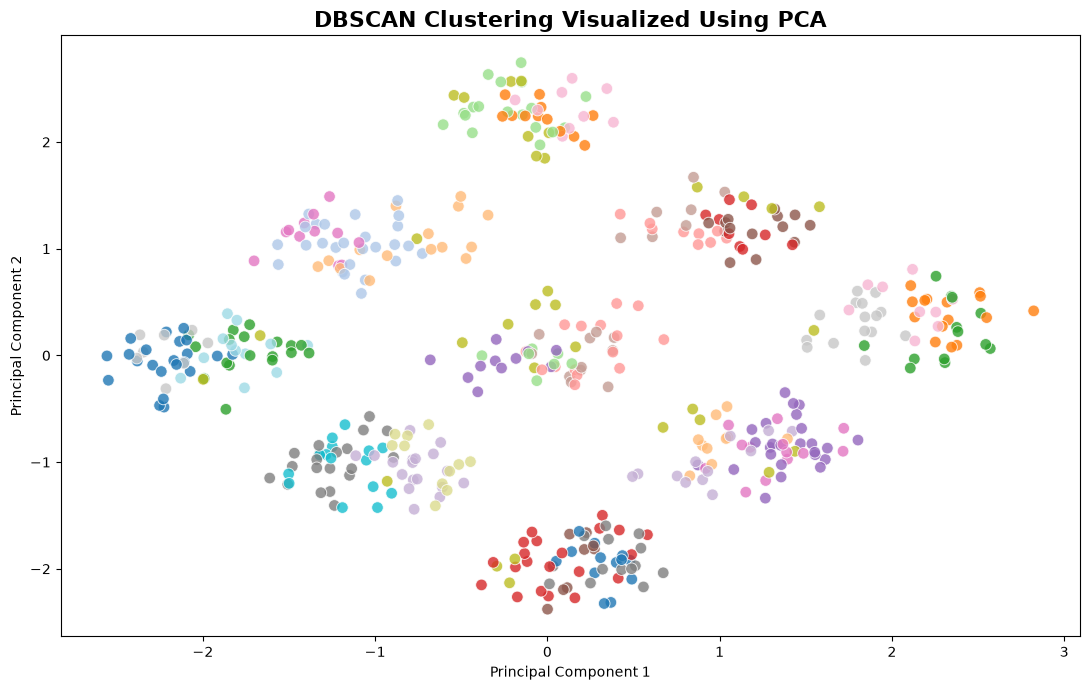

In [29]:
# Visualize DBSCAN clusters using PCA

dbscan_pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

dbscan_pca_df["Cluster"] = dbscan_labels_final.astype(str)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=dbscan_pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab20",
    s=70,
    alpha=0.8,
    legend=False
)

plt.title(
    "DBSCAN Clustering Visualized Using PCA",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.savefig(
    "visualizations/dbscan_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Calculate silhouette scores for K-Means and DBSCAN

kmeans_silhouette = silhouette_score(
    clustering_scaled,
    cluster_labels
)

# DBSCAN silhouette score excluding noise points
dbscan_mask = dbscan_labels_final != -1

if len(set(dbscan_labels_final[dbscan_mask])) > 1:
    dbscan_silhouette = silhouette_score(
        clustering_scaled[dbscan_mask],
        dbscan_labels_final[dbscan_mask]
    )
else:
    dbscan_silhouette = np.nan

# Create comparison table
clustering_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Number of Clusters": [
        len(set(cluster_labels)),
        len(set(hierarchical_labels)),
        dbscan_cluster_count
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ]
})

clustering_comparison["Silhouette Score"] = (
    clustering_comparison["Silhouette Score"].round(4)
)

display(clustering_comparison)

,Algorithm,Number of Clusters,Silhouette Score
0,K-Means,5,0.1478
1,Hierarchical,5,0.1309
2,DBSCAN,35,0.2317


In [31]:
# Create final customer segment profiles

segment_profiles = df.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Tenure=("Tenure", "mean"),
    Avg_MonthlyCharges=("MonthlyCharges", "mean"),
    Avg_TotalCharges=("TotalCharges", "mean"),
    SeniorCitizen_Percentage=("SeniorCitizen", "mean"),
    Churn_Rate=("Churn", "mean")
).reset_index()

# Convert proportions to percentages
segment_profiles["SeniorCitizen_Percentage"] = (
    segment_profiles["SeniorCitizen_Percentage"] * 100
).round(2)

segment_profiles["Churn_Rate"] = (
    segment_profiles["Churn_Rate"] * 100
).round(2)

# Add customer percentage
segment_profiles["Customer_Percentage"] = (
    segment_profiles["Customers"] / len(df) * 100
).round(2)

# Round numerical values
segment_profiles["Avg_Tenure"] = segment_profiles["Avg_Tenure"].round(2)
segment_profiles["Avg_MonthlyCharges"] = segment_profiles["Avg_MonthlyCharges"].round(2)
segment_profiles["Avg_TotalCharges"] = segment_profiles["Avg_TotalCharges"].round(2)

# Arrange columns
segment_profiles = segment_profiles[
    [
        "Segment",
        "Customers",
        "Customer_Percentage",
        "Avg_Tenure",
        "Avg_MonthlyCharges",
        "Avg_TotalCharges",
        "SeniorCitizen_Percentage",
        "Churn_Rate"
    ]
]

display(segment_profiles)

,Segment,Customers,Customer_Percentage,Avg_Tenure,Avg_MonthlyCharges,Avg_TotalCharges,SeniorCitizen_Percentage,Churn_Rate
0,High-Charge Electronic Check Customers,101,20.2,36.28,121.08,4165.61,45.54,13.86
1,Long-Term Customers,97,19.4,34.88,110.90,4597.04,54.64,7.22
2,Low-Churn One-Year Customers,124,24.8,38.39,115.25,3976.46,45.16,3.23
3,Month-to-Month At-Risk Customers,116,23.2,36.35,108.85,4260.77,55.17,20.69
4,One-Year Electronic Check Customers,62,12.4,36.16,111.52,4273.73,48.39,6.45


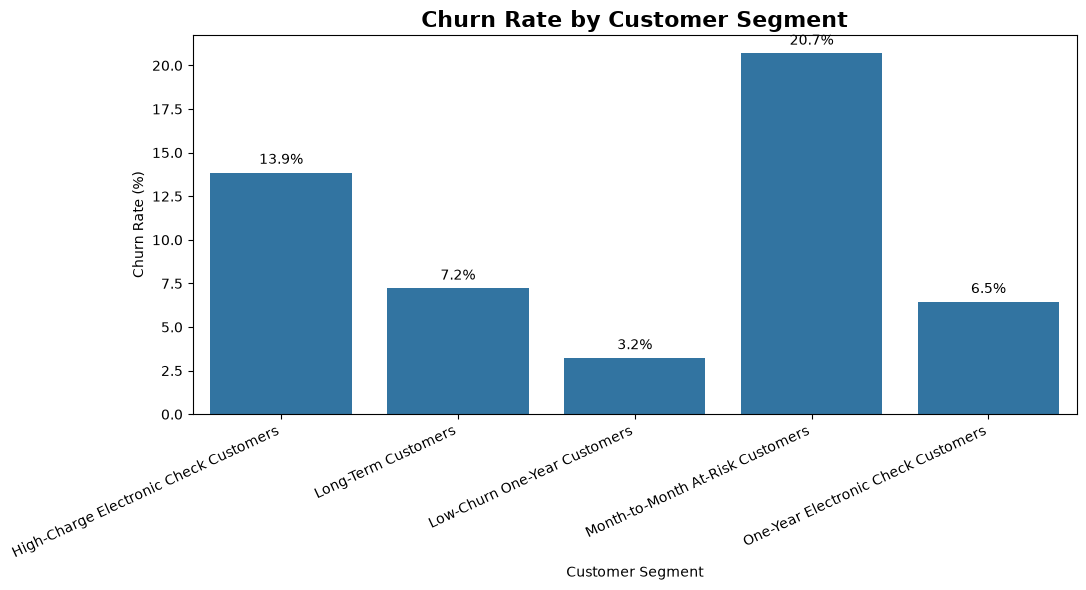

In [32]:
# Visualize churn rate across customer segments

plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_profiles,
    x="Segment",
    y="Churn_Rate"
)

plt.title(
    "Churn Rate by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

# Add percentage labels
for i, value in enumerate(segment_profiles["Churn_Rate"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "visualizations/churn_rate_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Check churn distribution within each customer segment

segment_churn_distribution = pd.crosstab(
    df["Segment"],
    df["Churn"]
)

segment_churn_distribution.columns = [
    "No_Churn",
    "Churn"
]

segment_churn_distribution["Total"] = (
    segment_churn_distribution["No_Churn"]
    + segment_churn_distribution["Churn"]
)

segment_churn_distribution["Churn_Rate"] = (
    segment_churn_distribution["Churn"]
    / segment_churn_distribution["Total"]
    * 100
).round(2)

display(segment_churn_distribution)

,No_Churn,Churn,Total,Churn_Rate
Segment,,,,
High-Charge Electronic Check Customers,87,14,101,13.86
Long-Term Customers,90,7,97,7.22
Low-Churn One-Year Customers,120,4,124,3.23
Month-to-Month At-Risk Customers,92,24,116,20.69
One-Year Electronic Check Customers,58,4,62,6.45


In [34]:
# Prepare features and target for segment-specific prediction

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create prediction dataset
prediction_df = df.drop(
    columns=["CustomerID", "Cluster", "Segment"]
).copy()

# Separate target
X = prediction_df.drop(columns=["Churn"])
y = prediction_df["Churn"]

# Convert categorical variables into numerical features
X_encoded = pd.get_dummies(
    X,
    columns=["Contract", "PaymentMethod", "PaperlessBilling"],
    drop_first=True,
    dtype=int
)

print("Prediction features shape:", X_encoded.shape)
print("Target shape:", y.shape)

print("\nPrediction features:")
print(list(X_encoded.columns))

Prediction features shape: (500, 9)
Target shape: (500,)

Prediction features:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check', 'PaperlessBilling_Yes']


In [35]:
# Check the prediction data available for each segment

segment_data_summary = []

for segment in segment_names.values():
    segment_mask = df["Segment"] == segment
    
    X_segment = X_encoded.loc[segment_mask]
    y_segment = y.loc[segment_mask]
    
    segment_data_summary.append({
        "Segment": segment,
        "Customers": len(y_segment),
        "No_Churn": (y_segment == 0).sum(),
        "Churn": (y_segment == 1).sum()
    })

segment_data_summary = pd.DataFrame(segment_data_summary)

display(segment_data_summary)

,Segment,Customers,No_Churn,Churn
0,Long-Term Customers,97,90,7
1,High-Charge Electronic Check Customers,101,87,14
2,Month-to-Month At-Risk Customers,116,92,24
3,One-Year Electronic Check Customers,62,58,4
4,Low-Churn One-Year Customers,124,120,4


In [36]:
# Train baseline Random Forest models for each customer segment

baseline_models = {}
baseline_results = []

for segment in segment_names.values():
    
    segment_mask = df["Segment"] == segment
    
    X_segment = X_encoded.loc[segment_mask]
    y_segment = y.loc[segment_mask]
    
    # Skip segments where stratified splitting is not possible
    if y_segment.value_counts().min() < 2:
        print(f"Skipping {segment}: not enough samples in both classes.")
        continue
    
    # Stratified train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_segment,
        y_segment,
        test_size=0.30,
        random_state=42,
        stratify=y_segment
    )
    
    # Baseline Random Forest
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )
    
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    
    # ROC-AUC requires both classes in the test set
    if len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan
    
    baseline_models[segment] = model
    
    baseline_results.append({
        "Segment": segment,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    })

baseline_results_df = pd.DataFrame(baseline_results)

# Round metrics
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

baseline_results_df[metric_columns] = (
    baseline_results_df[metric_columns].round(4)
)

display(baseline_results_df)

,Segment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Long-Term Customers,0.9000,0.0,0.0,0.0000,0.9643
1,High-Charge Electronic Check Customers,0.9677,0.8,1.0,0.8889,0.9815
2,Month-to-Month At-Risk Customers,1.0000,1.0,1.0,1.0000,1.0000
3,One-Year Electronic Check Customers,1.0000,1.0,1.0,1.0000,1.0000
4,Low-Churn One-Year Customers,0.9737,0.0,0.0,0.0000,1.0000


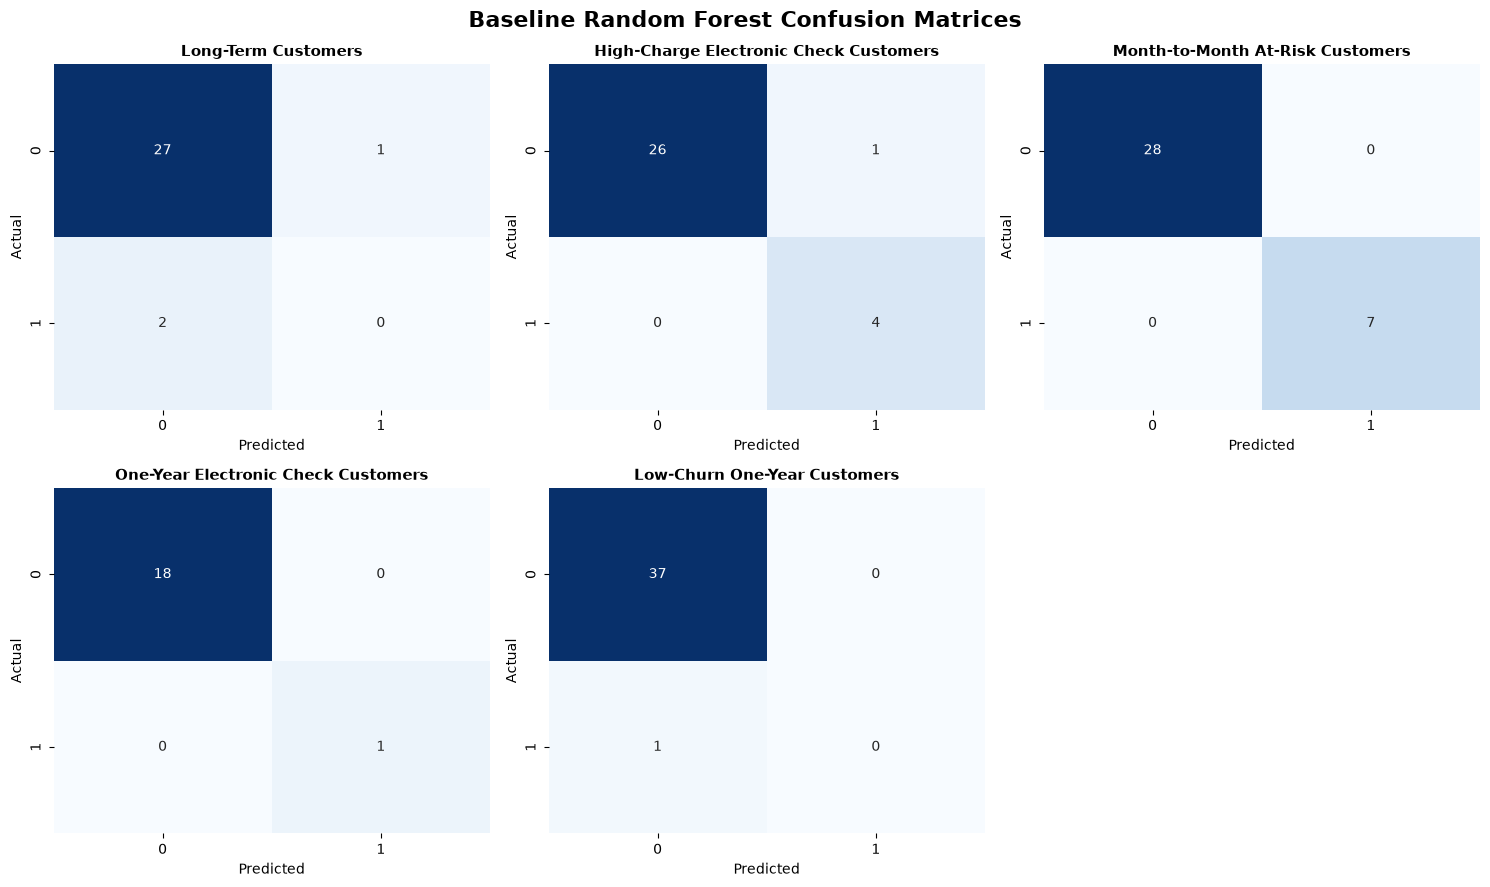

In [37]:
# Confusion matrices for baseline models

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, segment in enumerate(segment_names.values()):
    
    segment_mask = df["Segment"] == segment
    
    X_segment = X_encoded.loc[segment_mask]
    y_segment = y.loc[segment_mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_segment,
        y_segment,
        test_size=0.30,
        random_state=42,
        stratify=y_segment
    )
    
    model = baseline_models[segment]
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )
    
    axes[i].set_title(segment, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove unused subplot
if len(segment_names) < len(axes):
    for j in range(len(segment_names), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle(
    "Baseline Random Forest Confusion Matrices",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "visualizations/baseline_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Hyperparameter tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

tuned_models = {}
tuned_results = []

for segment in segment_names.values():

    segment_mask = df["Segment"] == segment

    X_segment = X_encoded.loc[segment_mask]
    y_segment = y.loc[segment_mask]

    # Number of positive and negative samples
    class_counts = y_segment.value_counts()

    min_class_count = class_counts.min()

    # Need at least 3 samples of each class for 3-fold CV
    if min_class_count < 3:
        print(f"Skipping tuning for {segment}: insufficient samples.")
        continue

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_segment,
        y_segment,
        test_size=0.30,
        random_state=42,
        stratify=y_segment
    )

    # 3-fold stratified cross-validation
    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    rf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    # Predictions
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    tuned_models[segment] = best_model

    tuned_results.append({
        "Segment": segment,
        "Best_Parameters": grid_search.best_params_,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    })

tuned_results_df = pd.DataFrame(tuned_results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

tuned_results_df[metric_columns] = (
    tuned_results_df[metric_columns].round(4)
)

display(tuned_results_df)

,Segment,Best_Parameters,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Long-Term Customers,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.9000,0.0,0.0,0.0000,0.9643
1,High-Charge Electronic Check Customers,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.9677,0.8,1.0,0.8889,0.9722
2,Month-to-Month At-Risk Customers,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.0000,1.0,1.0,1.0000,1.0000
3,One-Year Electronic Check Customers,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.0000,1.0,1.0,1.0000,1.0000
4,Low-Churn One-Year Customers,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.9737,0.0,0.0,0.0000,1.0000


In [39]:
# Compare baseline and tuned model performance

baseline_comparison = baseline_results_df[
    [
        "Segment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
].copy()

baseline_comparison["Model"] = "Baseline"

tuned_comparison = tuned_results_df[
    [
        "Segment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
].copy()

tuned_comparison["Model"] = "Tuned"

model_comparison = pd.concat(
    [baseline_comparison, tuned_comparison],
    ignore_index=True
)

model_comparison = model_comparison[
    [
        "Segment",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
]

display(model_comparison)

,Segment,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Long-Term Customers,Baseline,0.9000,0.0,0.0,0.0000,0.9643
1,High-Charge Electronic Check Customers,Baseline,0.9677,0.8,1.0,0.8889,0.9815
2,Month-to-Month At-Risk Customers,Baseline,1.0000,1.0,1.0,1.0000,1.0000
3,One-Year Electronic Check Customers,Baseline,1.0000,1.0,1.0,1.0000,1.0000
4,Low-Churn One-Year Customers,Baseline,0.9737,0.0,0.0,0.0000,1.0000
5,Long-Term Customers,Tuned,0.9000,0.0,0.0,0.0000,0.9643
6,High-Charge Electronic Check Customers,Tuned,0.9677,0.8,1.0,0.8889,0.9722
7,Month-to-Month At-Risk Customers,Tuned,1.0000,1.0,1.0,1.0000,1.0000
8,One-Year Electronic Check Customers,Tuned,1.0000,1.0,1.0,1.0000,1.0000
9,Low-Churn One-Year Customers,Tuned,0.9737,0.0,0.0,0.0000,1.0000


In [40]:
# Analyze feature importance for tuned Random Forest models

feature_importance_results = []

for segment, model in tuned_models.items():

    importances = model.feature_importances_

    for feature, importance in zip(
        X_encoded.columns,
        importances
    ):
        feature_importance_results.append({
            "Segment": segment,
            "Feature": feature,
            "Importance": importance
        })

feature_importance_df = pd.DataFrame(
    feature_importance_results
)

feature_importance_df["Importance"] = (
    feature_importance_df["Importance"].round(4)
)

# Display top 5 features for each segment
for segment in tuned_models.keys():

    print(f"\n{'=' * 70}")
    print(f"Feature Importance — {segment}")
    print(f"{'=' * 70}")

    top_features = (
        feature_importance_df[
            feature_importance_df["Segment"] == segment
        ]
        .sort_values("Importance", ascending=False)
        .head(5)
    )

    display(top_features)


Feature Importance — Long-Term Customers


,Segment,Feature,Importance
0,Long-Term Customers,Tenure,0.5630
1,Long-Term Customers,MonthlyCharges,0.2128
2,Long-Term Customers,TotalCharges,0.1178
3,Long-Term Customers,SeniorCitizen,0.0583
8,Long-Term Customers,PaperlessBilling_Yes,0.0284



Feature Importance — High-Charge Electronic Check Customers


,Segment,Feature,Importance
9,High-Charge Electronic Check Customers,Tenure,0.7140
10,High-Charge Electronic Check Customers,MonthlyCharges,0.1102
11,High-Charge Electronic Check Customers,TotalCharges,0.0861
17,High-Charge Electronic Check Customers,PaperlessBilling_Yes,0.0344
14,High-Charge Electronic Check Customers,Contract_Two year,0.0297



Feature Importance — Month-to-Month At-Risk Customers


,Segment,Feature,Importance
18,Month-to-Month At-Risk Customers,Tenure,0.7849
19,Month-to-Month At-Risk Customers,MonthlyCharges,0.1018
20,Month-to-Month At-Risk Customers,TotalCharges,0.0684
26,Month-to-Month At-Risk Customers,PaperlessBilling_Yes,0.0185
24,Month-to-Month At-Risk Customers,PaymentMethod_Credit Card,0.0166



Feature Importance — One-Year Electronic Check Customers


,Segment,Feature,Importance
27,One-Year Electronic Check Customers,Tenure,0.4981
28,One-Year Electronic Check Customers,MonthlyCharges,0.2541
29,One-Year Electronic Check Customers,TotalCharges,0.1515
35,One-Year Electronic Check Customers,PaperlessBilling_Yes,0.0753
30,One-Year Electronic Check Customers,SeniorCitizen,0.0210



Feature Importance — Low-Churn One-Year Customers


,Segment,Feature,Importance
36,Low-Churn One-Year Customers,Tenure,0.5862
37,Low-Churn One-Year Customers,MonthlyCharges,0.2588
38,Low-Churn One-Year Customers,TotalCharges,0.1258
44,Low-Churn One-Year Customers,PaperlessBilling_Yes,0.0107
39,Low-Churn One-Year Customers,SeniorCitizen,0.0100


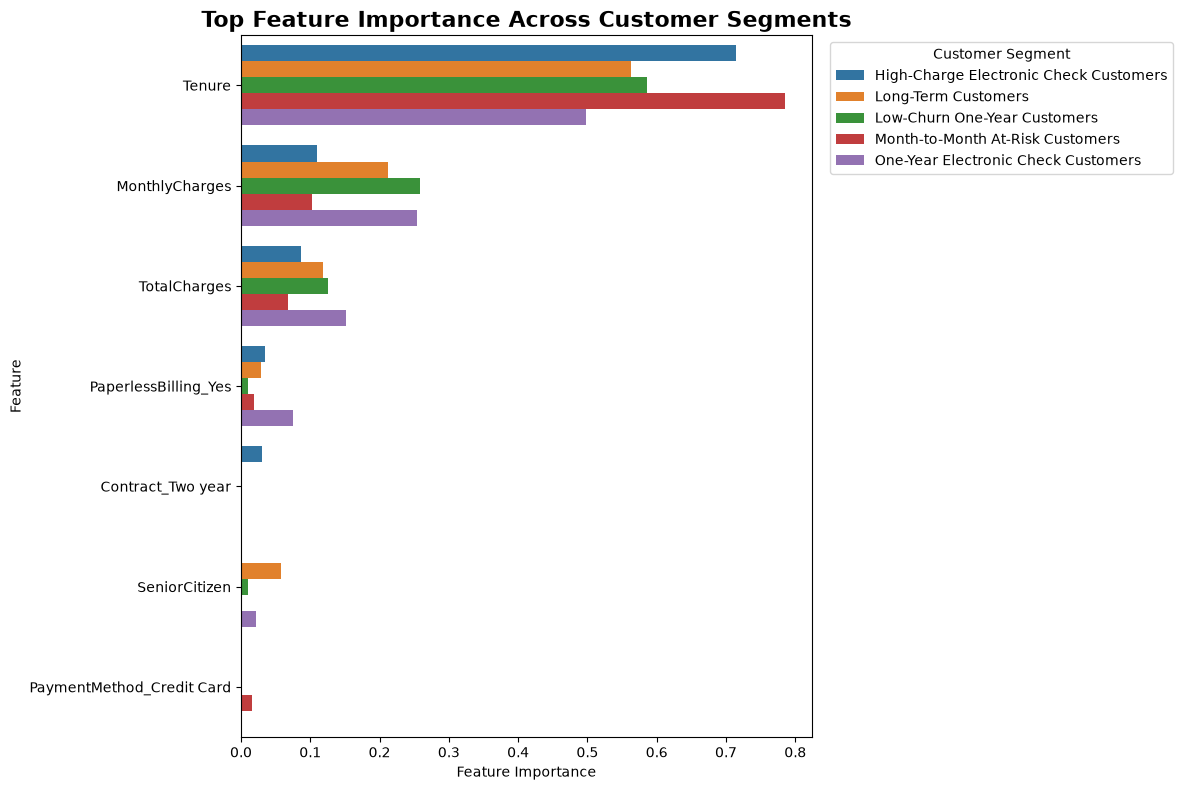

In [41]:
# Visualize top feature importance for each segment

top_features_all = (
    feature_importance_df
    .sort_values(
        ["Segment", "Importance"],
        ascending=[True, False]
    )
    .groupby("Segment")
    .head(5)
    .copy()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features_all,
    x="Importance",
    y="Feature",
    hue="Segment"
)

plt.title(
    "Top Feature Importance Across Customer Segments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "visualizations/feature_importance_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# Save final model evaluation results

final_model_results = tuned_results_df[
    [
        "Segment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
].copy()

final_model_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)

print("model_evaluation_results.csv created successfully!")
display(final_model_results)

model_evaluation_results.csv created successfully!


,Segment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Long-Term Customers,0.9000,0.0,0.0,0.0000,0.9643
1,High-Charge Electronic Check Customers,0.9677,0.8,1.0,0.8889,0.9722
2,Month-to-Month At-Risk Customers,1.0000,1.0,1.0,1.0000,1.0000
3,One-Year Electronic Check Customers,1.0000,1.0,1.0,1.0000,1.0000
4,Low-Churn One-Year Customers,0.9737,0.0,0.0,0.0000,1.0000


In [49]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "reportlab"
])

0

In [50]:
import reportlab

print("ReportLab version:", reportlab.Version)
print("ReportLab installed successfully!")

ReportLab version: 5.0.1
ReportLab installed successfully!


In [51]:
# Create Business Recommendations PDF

from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch


pdf_path = "business_recommendations.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = styles["Title"]
title_style.alignment = TA_CENTER

heading_style = styles["Heading2"]
body_style = styles["BodyText"]

story = []

# Title
story.append(
    Paragraph(
        "Customer Segmentation & Prediction",
        title_style
    )
)

story.append(
    Paragraph(
        "Business Recommendations",
        styles["Heading2"]
    )
)

story.append(Spacer(1, 15))

# Overview
story.append(
    Paragraph(
        "<b>Project Overview</b>",
        heading_style
    )
)

story.append(
    Paragraph(
        "The analysis segmented 500 customers into five customer groups "
        "using K-Means clustering and developed segment-specific Random "
        "Forest prediction models for churn analysis.",
        body_style
    )
)

story.append(Spacer(1, 12))


# Recommendations
recommendations = [
    [
        "Customer Segment",
        "Observed Churn",
        "Business Recommendations"
    ],
    [
        "Long-Term Customers",
        "7.22%",
        "Maintain loyalty programs, encourage renewals, "
        "and provide personalized account support."
    ],
    [
        "High-Charge Electronic Check Customers",
        "13.86%",
        "Monitor high-value customers, provide targeted "
        "retention offers, and promote convenient payment options."
    ],
    [
        "Low-Churn One-Year Customers",
        "3.23%",
        "Maintain customer experience, encourage renewals, "
        "and develop loyalty and referral programs."
    ],
    [
        "Month-to-Month At-Risk Customers",
        "20.69%",
        "Use targeted retention campaigns, communicate the "
        "benefits of longer contracts, and monitor churn signals."
    ],
    [
        "One-Year Electronic Check Customers",
        "6.45%",
        "Encourage convenient payment alternatives and "
        "maintain proactive contract-renewal communication."
    ]
]

table = Table(
    recommendations,
    colWidths=[1.55 * inch, 0.9 * inch, 4.0 * inch]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1f4e78")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, 0), 9),
        ("FONTSIZE", (0, 1), (-1, -1), 8),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1),
         [colors.whitesmoke, colors.lightgrey]),
        ("LEFTPADDING", (0, 0), (-1, -1), 6),
        ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ("TOPPADDING", (0, 0), (-1, -1), 6),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(table)

story.append(Spacer(1, 20))

# Model findings
story.append(
    Paragraph(
        "<b>Model Findings</b>",
        heading_style
    )
)

model_findings = [
    "K-Means produced five customer segments used for the main prediction pipeline.",
    "Hierarchical Clustering was also evaluated as a second clustering method.",
    "DBSCAN was evaluated as a density-based clustering method and produced 35 clusters with 6.4% of observations classified as noise at the selected parameters.",
    "Random Forest models were trained separately for each customer segment.",
    "GridSearchCV was applied for hyperparameter tuning.",
    "Tenure was the most important feature across the segment-specific Random Forest models, followed by MonthlyCharges and TotalCharges."
]

for finding in model_findings:
    story.append(
        Paragraph(
            f"• {finding}",
            body_style
        )
    )
    story.append(Spacer(1, 5))

story.append(Spacer(1, 10))

# Limitations
story.append(
    Paragraph(
        "<b>Model Limitations</b>",
        heading_style
    )
)

limitations = [
    "Some segments contain very few churned customers, which makes precision, recall, and F1-score less stable.",
    "The PCA visualization represents only 34.10% of total variance using its first two components.",
    "Feature importance indicates how the Random Forest models used the features; it does not establish causal relationships.",
    "Business recommendations should be validated with additional customer and business data before implementation."
]

for limitation in limitations:
    story.append(
        Paragraph(
            f"• {limitation}",
            body_style
        )
    )
    story.append(Spacer(1, 5))

doc.build(story)

print(f"Created successfully: {pdf_path}")

Created successfully: business_recommendations.pdf


In [52]:
import shutil

shutil.copy("customer_segmentation.csv", "segmentation_data.csv")

print("Created successfully: segmentation_data.csv")

Created successfully: segmentation_data.csv
